In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_phenotype = pd.read_excel("phenotype_labelled.xlsx")
df_phenotype

,sample,id,disease_type,case_id,submitter_id,primary_site,alcohol_history.exposures,race.demographic,gender.demographic,ethnicity.demographic,...,preservation_method.samples,intermediate_dimension.samples,pathology_report_uuid.samples,shortest_dimension.samples,oct_embedded.samples,specimen_type.samples,longest_dimension.samples,is_ffpe.samples,tissue_type.samples,annotations.samples
0,TCGA-XK-AAK1-01A,1bc21d56-299d-40bc-b9c8-c74db990611e,Adenomas and Adenocarcinomas,1bc21d56-299d-40bc-b9c8-c74db990611e,TCGA-XK-AAK1,Prostate gland,Not Reported,white,male,not reported,...,OCT,NaN,55565AD3-723E-4899-BBEA-D6FDF557E4C6,NaN,1.0,Solid Tissue,NaN,False,Tumor,NaN
1,TCGA-EJ-A46E-01A,a608bf0e-a932-4541-8439-2ffb9f6294b0,Adenomas and Adenocarcinomas,a608bf0e-a932-4541-8439-2ffb9f6294b0,TCGA-EJ-A46E,Prostate gland,Not Reported,white,male,not hispanic or latino,...,OCT,NaN,F2A59B31-7CFE-4DA8-A7B7-229021357746,NaN,1.0,Solid Tissue,NaN,False,Tumor,NaN
2,TCGA-HC-7748-01A,f6040682-4999-4d71-abc2-354b473c6980,Adenomas and Adenocarcinomas,f6040682-4999-4d71-abc2-354b473c6980,TCGA-HC-7748,Prostate gland,Not Reported,white,male,not hispanic or latino,...,Unknown,0.7,6516e000-dc8c-4715-a561-ee47a114ad23,0.4,NaN,Solid Tissue,0.8,False,Tumor,NaN
3,TCGA-EJ-5542-01A,5a92ec4c-36ee-4588-aca2-e3303f29c7ad,Adenomas and Adenocarcinomas,5a92ec4c-36ee-4588-aca2-e3303f29c7ad,TCGA-EJ-5542,Prostate gland,Not Reported,white,male,not hispanic or latino,...,Unknown,0.9,d6fe7cc6-45e5-4b6c-b1f4-1dd7fd3c27be,0.4,NaN,Solid Tissue,1.7,False,Tumor,NaN
4,TCGA-XK-AAJ3-01A,06c9eb11-6018-4015-9fbe-b46886b2c3e0,Adenomas and Adenocarcinomas,06c9eb11-6018-4015-9fbe-b46886b2c3e0,TCGA-XK-AAJ3,Prostate gland,Not Reported,white,male,not reported,...,OCT,NaN,6DAD48EB-0C26-4417-A2C1-57332165EEF2,NaN,1.0,Solid Tissue,NaN,False,Tumor,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
567,TCGA-G9-6366-01A,df3abb97-c790-4ff6-a726-6645b3058d72,Adenomas and Adenocarcinomas,df3abb97-c790-4ff6-a726-6645b3058d72,TCGA-G9-6366,Prostate gland,Not Reported,white,male,not hispanic or latino,...,Unknown,1.2,6ef07861-a4db-4aa2-ba73-4cd43e10d72f,0.2,NaN,Solid Tissue,1.8,False,Tumor,NaN
568,TCGA-2A-AAYF-01A,490e84ed-3c02-4593-990e-ade5c109df44,Adenomas and Adenocarcinomas,490e84ed-3c02-4593-990e-ade5c109df44,TCGA-2A-AAYF,Prostate gland,Not Reported,white,male,not hispanic or latino,...,OCT,NaN,106166DD-946C-4DD0-85CA-5400104959DB,NaN,1.0,Solid Tissue,NaN,False,Tumor,NaN
569,TCGA-KK-A59Z-01A,df7bbd9c-0b35-4855-acde-46f4956f4df1,Adenomas and Adenocarcinomas,df7bbd9c-0b35-4855-acde-46f4956f4df1,TCGA-KK-A59Z,Prostate gland,Not Reported,black or african american,male,not reported,...,OCT,NaN,DDF6F24F-4406-49EE-9EE0-7129D8544677,NaN,1.0,Solid Tissue,NaN,False,Tumor,NaN
570,TCGA-YL-A8S8-01A,494a8495-8d10-4a8f-8664-f68ac339c889,Adenomas and Adenocarcinomas,494a8495-8d10-4a8f-8664-f68ac339c889,TCGA-YL-A8S8,Prostate gland,Not Reported,white,male,not hispanic or latino,...,OCT,NaN,6D4A3078-4C6B-4E94-B859-CCA473B09CF9,NaN,1.0,Solid Tissue,NaN,False,Tumor,NaN


In [3]:
df_phenotype = df_phenotype.dropna(subset=['Stage (Label)'])
df_phenotype

,sample,id,disease_type,case_id,submitter_id,primary_site,alcohol_history.exposures,race.demographic,gender.demographic,ethnicity.demographic,...,preservation_method.samples,intermediate_dimension.samples,pathology_report_uuid.samples,shortest_dimension.samples,oct_embedded.samples,specimen_type.samples,longest_dimension.samples,is_ffpe.samples,tissue_type.samples,annotations.samples
0,TCGA-XK-AAK1-01A,1bc21d56-299d-40bc-b9c8-c74db990611e,Adenomas and Adenocarcinomas,1bc21d56-299d-40bc-b9c8-c74db990611e,TCGA-XK-AAK1,Prostate gland,Not Reported,white,male,not reported,...,OCT,NaN,55565AD3-723E-4899-BBEA-D6FDF557E4C6,NaN,1.0,Solid Tissue,NaN,False,Tumor,NaN
1,TCGA-EJ-A46E-01A,a608bf0e-a932-4541-8439-2ffb9f6294b0,Adenomas and Adenocarcinomas,a608bf0e-a932-4541-8439-2ffb9f6294b0,TCGA-EJ-A46E,Prostate gland,Not Reported,white,male,not hispanic or latino,...,OCT,NaN,F2A59B31-7CFE-4DA8-A7B7-229021357746,NaN,1.0,Solid Tissue,NaN,False,Tumor,NaN
3,TCGA-EJ-5542-01A,5a92ec4c-36ee-4588-aca2-e3303f29c7ad,Adenomas and Adenocarcinomas,5a92ec4c-36ee-4588-aca2-e3303f29c7ad,TCGA-EJ-5542,Prostate gland,Not Reported,white,male,not hispanic or latino,...,Unknown,0.9,d6fe7cc6-45e5-4b6c-b1f4-1dd7fd3c27be,0.4,NaN,Solid Tissue,1.7,False,Tumor,NaN
4,TCGA-XK-AAJ3-01A,06c9eb11-6018-4015-9fbe-b46886b2c3e0,Adenomas and Adenocarcinomas,06c9eb11-6018-4015-9fbe-b46886b2c3e0,TCGA-XK-AAJ3,Prostate gland,Not Reported,white,male,not reported,...,OCT,NaN,6DAD48EB-0C26-4417-A2C1-57332165EEF2,NaN,1.0,Solid Tissue,NaN,False,Tumor,NaN
5,TCGA-EJ-A46H-01A,cec1d2ff-36e6-497e-892c-b329724b4722,Adenomas and Adenocarcinomas,cec1d2ff-36e6-497e-892c-b329724b4722,TCGA-EJ-A46H,Prostate gland,Not Reported,black or african american,male,not hispanic or latino,...,OCT,NaN,CF251041-E282-4840-9652-67665E7B10BB,NaN,1.0,Solid Tissue,NaN,False,Tumor,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,TCGA-V1-A9ZG-01A,dec99f86-622b-477f-a26a-98c954fb1f17,Adenomas and Adenocarcinomas,dec99f86-622b-477f-a26a-98c954fb1f17,TCGA-V1-A9ZG,Prostate gland,Not Reported,white,male,not hispanic or latino,...,OCT,NaN,D7B1ABAE-1A72-496C-B11F-469F65B37347,NaN,1.0,Solid Tissue,NaN,False,Tumor,NaN
565,TCGA-VP-A87J-01A,486d225f-eca6-499b-a142-dd86137b22e4,Adenomas and Adenocarcinomas,486d225f-eca6-499b-a142-dd86137b22e4,TCGA-VP-A87J,Prostate gland,Not Reported,black or african american,male,not reported,...,OCT,NaN,03F4F8F1-ACE1-4391-85AC-A10B2F56CDD0,NaN,1.0,Solid Tissue,NaN,False,Tumor,NaN
566,TCGA-EJ-5502-01A,48e83a4c-c602-494a-80cd-e2f4b4dd701e,Adenomas and Adenocarcinomas,48e83a4c-c602-494a-80cd-e2f4b4dd701e,TCGA-EJ-5502,Prostate gland,Not Reported,not reported,male,not reported,...,Unknown,1.0,173e45e9-e2ab-4a1d-8bcc-15374f1ae511,0.3,NaN,Solid Tissue,1.7,False,Tumor,NaN
569,TCGA-KK-A59Z-01A,df7bbd9c-0b35-4855-acde-46f4956f4df1,Adenomas and Adenocarcinomas,df7bbd9c-0b35-4855-acde-46f4956f4df1,TCGA-KK-A59Z,Prostate gland,Not Reported,black or african american,male,not reported,...,OCT,NaN,DDF6F24F-4406-49EE-9EE0-7129D8544677,NaN,1.0,Solid Tissue,NaN,False,Tumor,NaN


In [4]:
df_phenotype['race.demographic'].value_counts()

white                               303
black or african american            46
not reported                         10
asian                                 8
american indian or alaska native      1
Name: race.demographic, dtype: int64

In [5]:
df_white = df_phenotype[df_phenotype['race.demographic'] == 'white']
df_white

,sample,id,disease_type,case_id,submitter_id,primary_site,alcohol_history.exposures,race.demographic,gender.demographic,ethnicity.demographic,...,preservation_method.samples,intermediate_dimension.samples,pathology_report_uuid.samples,shortest_dimension.samples,oct_embedded.samples,specimen_type.samples,longest_dimension.samples,is_ffpe.samples,tissue_type.samples,annotations.samples
0,TCGA-XK-AAK1-01A,1bc21d56-299d-40bc-b9c8-c74db990611e,Adenomas and Adenocarcinomas,1bc21d56-299d-40bc-b9c8-c74db990611e,TCGA-XK-AAK1,Prostate gland,Not Reported,white,male,not reported,...,OCT,NaN,55565AD3-723E-4899-BBEA-D6FDF557E4C6,NaN,1.0,Solid Tissue,NaN,False,Tumor,NaN
1,TCGA-EJ-A46E-01A,a608bf0e-a932-4541-8439-2ffb9f6294b0,Adenomas and Adenocarcinomas,a608bf0e-a932-4541-8439-2ffb9f6294b0,TCGA-EJ-A46E,Prostate gland,Not Reported,white,male,not hispanic or latino,...,OCT,NaN,F2A59B31-7CFE-4DA8-A7B7-229021357746,NaN,1.0,Solid Tissue,NaN,False,Tumor,NaN
3,TCGA-EJ-5542-01A,5a92ec4c-36ee-4588-aca2-e3303f29c7ad,Adenomas and Adenocarcinomas,5a92ec4c-36ee-4588-aca2-e3303f29c7ad,TCGA-EJ-5542,Prostate gland,Not Reported,white,male,not hispanic or latino,...,Unknown,0.9,d6fe7cc6-45e5-4b6c-b1f4-1dd7fd3c27be,0.4,NaN,Solid Tissue,1.7,False,Tumor,NaN
4,TCGA-XK-AAJ3-01A,06c9eb11-6018-4015-9fbe-b46886b2c3e0,Adenomas and Adenocarcinomas,06c9eb11-6018-4015-9fbe-b46886b2c3e0,TCGA-XK-AAJ3,Prostate gland,Not Reported,white,male,not reported,...,OCT,NaN,6DAD48EB-0C26-4417-A2C1-57332165EEF2,NaN,1.0,Solid Tissue,NaN,False,Tumor,NaN
7,TCGA-EJ-7312-01B,00dda860-53c3-4ab2-8294-73e291adf9d2,Adenomas and Adenocarcinomas,00dda860-53c3-4ab2-8294-73e291adf9d2,TCGA-EJ-7312,Prostate gland,Not Reported,white,male,not hispanic or latino,...,OCT,NaN,92D81258-C134-48A6-8B74-DE3789E1530F,NaN,1.0,Solid Tissue,NaN,False,Tumor,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
556,TCGA-EJ-7328-11A,42b7d14f-09e5-4d91-bb98-5fe35907a6a9,Adenomas and Adenocarcinomas,42b7d14f-09e5-4d91-bb98-5fe35907a6a9,TCGA-EJ-7328,Prostate gland,Not Reported,white,male,not hispanic or latino,...,Unknown,1.2,NaN,0.3,NaN,Solid Tissue,2.0,False,Normal,NaN
560,TCGA-HC-A9TH-01A,433d1441-6d5b-4455-a731-65f172bb016d,Adenomas and Adenocarcinomas,433d1441-6d5b-4455-a731-65f172bb016d,TCGA-HC-A9TH,Prostate gland,Not Reported,white,male,not hispanic or latino,...,Unknown,NaN,C2755FC2-E4BD-4997-B2F9-1F1C3A9C28AE,NaN,0.0,Solid Tissue,NaN,False,Tumor,NaN
563,TCGA-EJ-7325-01B,45a04209-8fac-4181-bba3-1437c8fd7f09,Adenomas and Adenocarcinomas,45a04209-8fac-4181-bba3-1437c8fd7f09,TCGA-EJ-7325,Prostate gland,Not Reported,white,male,not hispanic or latino,...,OCT,NaN,6E9EC98C-FD89-47DA-BF8A-B7F4229C9E09,NaN,1.0,Solid Tissue,NaN,False,Tumor,NaN
564,TCGA-V1-A9ZG-01A,dec99f86-622b-477f-a26a-98c954fb1f17,Adenomas and Adenocarcinomas,dec99f86-622b-477f-a26a-98c954fb1f17,TCGA-V1-A9ZG,Prostate gland,Not Reported,white,male,not hispanic or latino,...,OCT,NaN,D7B1ABAE-1A72-496C-B11F-469F65B37347,NaN,1.0,Solid Tissue,NaN,False,Tumor,NaN


In [6]:
df_white['Stage (Label)'].value_counts()

IIC     102
IIIC     56
IVA      54
IIB      38
IIIA     30
IIIB     16
I         6
IIA       1
Name: Stage (Label), dtype: int64

In [7]:
stages = ["IIA", "IIB", "IIC", "IIIA", "IIIB", "IIIC"]

df_pheno = df_white[df_white['Stage (Label)'].isin(stages)]

early_stages = ["IIA", "IIB", "IIC"]
late_stages = ["IIIA", "IIIB", "IIIC"]

df_pheno['Stage_Binary'] = df_pheno['Stage (Label)'].map(
    lambda x: 0 if x in early_stages else (1 if x in late_stages else -1)
)
df_pheno['Stage_Binary'].value_counts(dropna=False)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_11648\4037613242.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_pheno['Stage_Binary'] = df_pheno['Stage (Label)'].map(


0    141
1    102
Name: Stage_Binary, dtype: int64

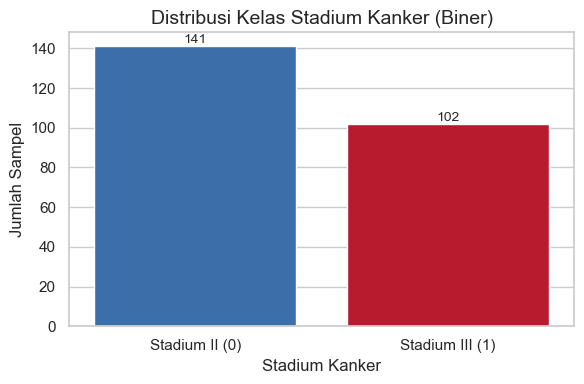

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set Seaborn style
sns.set(style="whitegrid")

# Improved custom palette using hex colors
custom_palette = {0: '#2A6EBB', 1: '#D0021B'}

# Create the bar plot
plt.figure(figsize=(6, 4))
ax = sns.countplot(
    x='Stage_Binary',
    data=df_pheno,
    palette=custom_palette
)

# Customize axis labels and title
ax.set_title('Distribusi Kelas Stadium Kanker (Biner)', fontsize=14)
ax.set_xlabel('Stadium Kanker', fontsize=12)
ax.set_ylabel('Jumlah Sampel', fontsize=12)
ax.set_xticklabels(['Stadium II (0)', 'Stadium III (1)'])

# Annotate bar counts
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height}', (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontsize=10)

# Display the plot
plt.tight_layout()
plt.show()


In [9]:
df_mirna2 =  pd.read_csv("TCGA-PRAD_mirna.tsv", sep="\t")
df_mirna2.T
df_mirna2

,miRNA_ID,TCGA-KK-A8IG-01A,TCGA-EJ-7792-11A,TCGA-HC-7079-01A,TCGA-VP-A87K-01A,TCGA-KK-A6E7-01A,TCGA-KK-A7AW-01A,TCGA-YL-A8SC-01A,TCGA-KC-A7FA-01A,TCGA-J4-A67T-01A,...,TCGA-G9-6362-11A,TCGA-EJ-A7NF-01A,TCGA-CH-5768-01A,TCGA-V1-A8MJ-01A,TCGA-V1-A8WL-01A,TCGA-G9-6351-01A,TCGA-HC-8266-01A,TCGA-YL-A8SF-01A,TCGA-HC-8262-11A,TCGA-KC-A7F6-01A
0,hsa-let-7a-1,13.415469,12.281069,12.514747,13.538915,13.733491,13.657055,14.150040,13.616230,13.213989,...,11.596397,13.865590,13.221815,12.916901,13.161131,12.990864,12.889421,12.851337,12.714859,13.277756
1,hsa-let-7a-2,13.405888,12.269381,12.530264,13.542210,13.735578,13.665545,14.136224,13.606036,13.193893,...,11.605834,13.854166,13.220680,12.899824,13.160582,13.009753,12.892662,12.845169,12.713055,13.276398
2,hsa-let-7a-3,13.406603,12.280710,12.519819,13.539121,13.733277,13.662519,14.156138,13.598870,13.190406,...,11.618878,13.860660,13.229452,12.910073,13.153461,13.005680,12.908348,12.849248,12.701629,13.266149
3,hsa-let-7b,12.356451,11.784868,13.560271,13.732097,13.679594,13.165108,13.318881,12.032979,12.777939,...,11.308530,12.458854,12.479363,13.131916,12.039470,13.272546,13.073386,12.548149,12.593705,12.410085
4,hsa-let-7c,12.931139,12.447245,12.016928,11.904369,13.503764,12.528967,14.014723,11.990777,12.432594,...,12.162879,11.396777,12.062550,12.609745,13.220222,12.582456,12.541790,11.533923,12.573033,11.679126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1876,hsa-mir-9500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1877,hsa-mir-96,6.093583,2.078151,3.813848,5.529737,5.337586,5.579993,5.396261,5.164737,5.213038,...,4.580469,5.273222,4.782703,3.902701,5.099216,4.801679,3.485078,5.838014,0.893048,4.877368
1878,hsa-mir-98,5.504522,4.729735,4.935923,4.702027,5.810481,4.926379,5.014609,4.898700,4.610753,...,5.027207,4.244364,4.732631,4.918925,5.403584,4.365086,5.257096,4.411958,4.701947,4.454220
1879,hsa-mir-99a,11.234018,11.249176,11.103455,11.059523,11.048350,10.687320,11.980509,10.866929,10.544157,...,10.165296,10.337203,10.152387,10.848491,11.417275,11.983876,11.716389,10.980470,11.436706,10.524828


In [10]:
# Prepare miRNA data for Merging
df_mirna = pd.read_csv("TCGA-PRAD_mirna.tsv", sep="\t")
df_mirna_transposed = df_mirna.T.reset_index()
df_mirna_transposed.columns = df_mirna_transposed.iloc[0]
df_mirna_transposed = df_mirna_transposed[1:].reset_index(drop=True)
df_mirna_transposed

,miRNA_ID,hsa-let-7a-1,hsa-let-7a-2,hsa-let-7a-3,hsa-let-7b,hsa-let-7c,hsa-let-7d,hsa-let-7e,hsa-let-7f-1,hsa-let-7f-2,...,hsa-mir-941-5,hsa-mir-942,hsa-mir-943,hsa-mir-944,hsa-mir-95,hsa-mir-9500,hsa-mir-96,hsa-mir-98,hsa-mir-99a,hsa-mir-99b
0,TCGA-KK-A8IG-01A,13.415469,13.405888,13.406603,12.356451,12.931139,8.284377,9.679941,12.661624,12.759622,...,0.0,1.356611,0.0,1.255442,2.632911,0.0,6.093583,5.504522,11.234018,13.552617
1,TCGA-EJ-7792-11A,12.281069,12.269381,12.28071,11.784868,12.447245,7.045894,8.452391,11.124647,11.107082,...,0.0,1.163166,0.0,1.990868,1.576848,0.0,2.078151,4.729735,11.249176,13.974765
2,TCGA-HC-7079-01A,12.514747,12.530264,12.519819,13.560271,12.016928,8.598683,8.726782,10.641436,10.625618,...,0.0,2.766775,0.0,2.703888,1.85305,0.0,3.813848,4.935923,11.103455,13.85753
3,TCGA-VP-A87K-01A,13.538915,13.54221,13.539121,13.732097,11.904369,8.932069,9.291107,11.386465,11.415504,...,0.0,1.672184,0.0,0.571427,1.43348,0.0,5.529737,4.702027,11.059523,14.149836
4,TCGA-KK-A6E7-01A,13.733491,13.735578,13.733277,13.679594,13.503764,8.68317,10.549271,12.321585,12.366904,...,0.0,1.084306,0.0,0.534203,1.883172,0.0,5.337586,5.810481,11.04835,15.130159
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
546,TCGA-G9-6351-01A,12.990864,13.009753,13.00568,13.272546,12.582456,8.09857,9.026343,10.957555,10.997239,...,0.0,0.879952,0.0,0.879952,1.084349,0.0,4.801679,4.365086,11.983876,13.970829
547,TCGA-HC-8266-01A,12.889421,12.892662,12.908348,13.073386,12.54179,7.926571,8.753227,11.571965,11.603346,...,0.0,2.036863,0.0,1.582615,1.582615,0.0,3.485078,5.257096,11.716389,13.615691
548,TCGA-YL-A8SF-01A,12.851337,12.845169,12.849248,12.548149,11.533923,8.606439,9.816808,10.882677,10.935536,...,0.0,1.67504,0.0,1.403246,0.630704,0.0,5.838014,4.411958,10.98047,14.667069
549,TCGA-HC-8262-11A,12.714859,12.713055,12.701629,12.593705,12.573033,6.834618,9.248322,11.546443,11.570549,...,0.0,0.425285,0.0,2.402034,0.425285,0.0,0.893048,4.701947,11.436706,13.797307


In [23]:
# Prepare gene data for Merging
df_gen = pd.read_csv("TCGA-PRAD_star_counts.tsv", sep="\t")
df_gen_transposed = df_gen.T.reset_index()
df_gen_transposed.columns = df_gen_transposed.iloc[0]
df_gen_transposed = df_gen_transposed[1:].reset_index(drop=True)

In [24]:
# Prepare All datasets for Merging

df_pheno_combined1 = df_pheno[['sample', 'Stage_Binary']].copy()

df_mirna_combined1 = df_mirna_transposed.copy()
df_mirna_combined1.rename(columns={'miRNA_ID': 'sample'}, inplace=True)

df_gen_combined1 = df_gen_transposed.copy()
df_gen_combined1.rename(columns={'Ensembl_ID': 'sample'}, inplace=True)

In [25]:
# Merge miRNA and Phenotype Data
df_miRNA_pheno = pd.merge(df_pheno_combined1, df_mirna_combined1, on='sample', how='inner')
df_miRNA_pheno

,sample,Stage_Binary,hsa-let-7a-1,hsa-let-7a-2,hsa-let-7a-3,hsa-let-7b,hsa-let-7c,hsa-let-7d,hsa-let-7e,hsa-let-7f-1,...,hsa-mir-941-5,hsa-mir-942,hsa-mir-943,hsa-mir-944,hsa-mir-95,hsa-mir-9500,hsa-mir-96,hsa-mir-98,hsa-mir-99a,hsa-mir-99b
0,TCGA-XK-AAK1-01A,0,13.828853,13.816449,13.829315,13.255251,14.432572,8.696589,9.493452,11.729231,...,0.0,1.734873,0.0,0.661865,0.0,0.0,4.897977,4.417812,13.064129,13.506156
1,TCGA-EJ-A46E-01A,1,13.090581,13.075043,13.083671,13.872337,12.673151,8.79556,10.05961,11.128706,...,0.0,1.329166,0.0,2.1793,1.229286,0.0,3.555335,4.693399,11.351981,14.775497
2,TCGA-EJ-5542-01A,0,13.471242,13.478297,13.482761,13.525095,12.975856,7.946032,9.635602,12.071656,...,0.0,1.855886,0.0,1.207812,1.207812,0.0,4.703281,5.138337,10.521298,14.420156
3,TCGA-XK-AAJ3-01A,1,12.975771,12.965713,13.000138,12.853963,13.395103,8.910643,9.359377,11.534743,...,0.0,1.235169,0.0,0.928068,2.056424,0.0,6.004295,4.879503,12.269582,13.699134
4,TCGA-EJ-7312-01B,1,13.160453,13.140922,13.141303,12.702783,12.193673,7.705699,9.466239,11.731536,...,0.0,1.043591,0.0,1.043591,0.844799,0.0,4.525007,4.271151,11.063321,13.736388
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
234,TCGA-EJ-7328-11A,0,12.024322,12.02238,12.045439,12.669091,13.18156,7.055677,8.872273,10.426564,...,0.0,0.923478,0.0,0.534401,0.0,0.0,1.229602,4.43454,12.031679,14.170755
235,TCGA-HC-A9TH-01A,1,13.437379,13.440881,13.453371,13.380828,11.494153,8.408823,9.890571,11.823206,...,0.0,1.224504,0.0,0.290179,1.786893,0.0,4.968076,5.067277,10.404214,13.886516
236,TCGA-EJ-7325-01B,1,13.032091,13.025104,13.036037,13.198792,11.82888,8.301453,8.949078,11.820389,...,0.0,0.399043,0.0,1.374713,1.374713,0.0,4.921923,4.709952,10.633384,13.121102
237,TCGA-V1-A9ZG-01A,1,13.271903,13.253966,13.264066,12.189029,13.456789,8.678096,9.894217,12.042092,...,0.0,1.097669,0.0,1.376357,0.542044,0.0,4.472852,5.689853,12.74135,14.816567


In [26]:
# Merge Gen and Phenotype Data
df_gene_pheno = pd.merge(df_pheno_combined1, df_gen_combined1, on='sample', how='inner')
df_gene_pheno

,sample,Stage_Binary,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,...,ENSG00000288661.1,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1
0,TCGA-XK-AAK1-01A,0,10.284246,0.0,9.255029,8.049849,5.754888,6.426265,8.988685,10.584023,...,0.0,0.0,3.584963,0.0,0.0,0.0,6.83289,0.0,2.584963,5.285402
1,TCGA-EJ-A46E-01A,1,11.131857,2.321928,10.336507,9.301496,7.044394,7.851749,10.514714,10.108524,...,0.0,0.0,4.459432,0.0,0.0,0.0,8.290019,0.0,3.321928,3.0
2,TCGA-EJ-5542-01A,0,12.546653,3.70044,10.881879,10.820179,8.005625,7.312883,11.221587,11.738092,...,0.0,0.0,4.169925,0.0,0.0,0.0,8.562242,0.0,1.584963,4.857981
3,TCGA-XK-AAJ3-01A,1,11.092096,0.0,10.009829,9.189825,6.84549,7.276124,9.489848,11.371232,...,0.0,0.0,5.129283,0.0,0.0,0.0,7.721099,0.0,3.0,4.954196
4,TCGA-EJ-7312-01B,1,11.349834,3.169925,10.301496,8.771489,6.629357,6.72792,9.179909,11.629357,...,0.0,0.0,3.584963,0.0,0.0,0.0,7.066089,0.0,2.321928,3.70044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
235,TCGA-EJ-7328-11A,0,11.546412,6.022368,10.372865,9.791163,8.060696,8.696968,11.642954,10.696098,...,0.0,0.0,2.0,0.0,0.0,0.0,8.768184,0.0,2.321928,4.169925
236,TCGA-HC-A9TH-01A,1,11.931107,1.0,11.168672,10.318543,8.044394,8.787903,10.741467,11.565102,...,0.0,0.0,4.857981,0.0,0.0,0.0,8.791163,0.0,3.459432,6.357552
237,TCGA-EJ-7325-01B,1,11.563673,0.0,9.805744,9.084808,5.392317,6.149747,8.546894,11.60964,...,0.0,0.0,2.807355,0.0,0.0,0.0,6.768184,0.0,2.0,5.169925
238,TCGA-V1-A9ZG-01A,1,11.946541,1.0,10.838416,9.945444,7.599913,8.897845,11.695228,12.405141,...,0.0,0.0,4.0,0.0,0.0,0.0,7.960002,0.0,3.906891,5.523562


In [ ]:
# Get the common sample values
common_samples = set(df_miRNA_pheno['sample']).intersection(df_gene_pheno['sample'])

# Filter both Merged Dataset to to contain the same samples
df_miRNA_pheno = df_miRNA_pheno[df_miRNA_pheno['sample'].isin(common_samples)]
df_gene_pheno = df_gene_pheno[df_gene_pheno['sample'].isin(common_samples)]

In [ ]:
df_miRNA_pheno.to_csv("mirna2.csv")

In [ ]:
df_merged2.to_csv("gene2.csv")